# Media vs Public: How AI Coverage in The Guardian Compares to Reddit Discussion (2020–2025)

**ST115 Managing and Visualising Data — Final Project**

**Candidate Numbers:** 60733, 69179

---

## Table of Contents

1. [Introduction](#1-introduction)
2. [Data Acquisition](#2-data-acquisition)
   - 2.1 [Guardian API](#21-guardian-api)
   - 2.2 [Reddit Data via Arctic Shift](#22-reddit-data-via-arctic-shift)
   - 2.3 [Tech Stock Prices via Yahoo Finance](#23-tech-stock-prices-via-yahoo-finance)
3. [Data Preparation](#3-data-preparation)
   - 3.1 [Initial Data Inspection (IDA)](#31-initial-data-inspection-ida)
   - 3.2 [Cleaning and Wrangling](#32-cleaning-and-wrangling)
   - 3.3 [Building a Unified Monthly Time Series](#33-building-a-unified-monthly-time-series)
4. [Exploratory Data Analysis (EDA)](#4-exploratory-data-analysis-eda)
   - 4.1 [Volume Distributions](#41-volume-distributions)
   - 4.2 [Guardian Section Breakdown](#42-guardian-section-breakdown)
   - 4.3 [Reddit Subreddit Breakdown](#43-reddit-subreddit-breakdown)
   - 4.4 [Word Frequency Exploration](#44-word-frequency-exploration)
5. [Main Analysis](#5-main-analysis)
   - 5.1 [RQ1: Volume Over Time](#51-rq1-volume-over-time)
   - 5.2 [RQ2: Topic and Theme Comparison](#52-rq2-topic-and-theme-comparison)
   - 5.3 [RQ3: Sentiment Comparison and Stock Prices](#53-rq3-sentiment-comparison-and-stock-prices)
6. [Conclusion](#6-conclusion)

---
## 1. Introduction

### Motivation

Artificial intelligence has arguably been the defining technological story of the past five years. The launch of ChatGPT in late 2022, followed by the rapid proliferation of generative AI tools, triggered a wave of media coverage, public debate, regulatory discussion, and cultural anxiety. But how do these two very different spaces — professional journalism and informal public discussion — actually differ in how they talk about AI?

Mainstream news organisations like The Guardian operate with editorial oversight, set agendas, and often frame AI in terms of policy and societal risk. Reddit, by contrast, is driven by organic public interest: users post what they find interesting or useful, vote on content, and discuss AI from a largely practical standpoint. These two sources represent fundamentally different perspectives on the same topic, and comparing them offers a window into the gap between how AI is *reported* and how it is *discussed*.

### Research Questions

This project addresses three research questions:

1. **How does the volume of AI-related content change over time across both sources, and what real-world events caused the biggest spikes?**
2. **Do The Guardian and Reddit focus on different topics and themes when discussing AI — for example, does The Guardian focus more on regulation and risk, while Reddit focuses more on tools and practical uses?**
3. **How does overall sentiment differ between Guardian articles and Reddit posts, and has this gap changed over time? Does sentiment in either source correlate with movements in tech stock prices?**

### Originality

While there is existing academic work on media framing of AI, direct comparison of professional journalism against large-scale public online discussion — across a five-year window covering the full generative AI era — is not widely available. By combining live API data from The Guardian, historical Reddit data from Arctic Shift, and financial data from Yahoo Finance, this project produces a genuinely data-driven picture of how AI discourse has evolved across both spaces.

---
## 2. Data Acquisition

We collect data from three sources. All collection code is included in this notebook so that results are fully reproducible. Raw data files are stored in the `data/` folder of this repository.

**Note:** To reproduce the Guardian API calls, you will need a free Guardian API key. Register at https://open-platform.theguardian.com/access/. Replace `YOUR_GUARDIAN_API_KEY` in the cell below with your key. The Arctic Shift and Yahoo Finance requests require no authentication.

In [46]:
# ── Core libraries ──────────────────────────────────────────────────────────
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from collections import Counter
import re
import time
import json
import os
from datetime import datetime

# ── NLP ─────────────────────────────────────────────────────────────────────
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords', quiet=True)

# ── Finance ──────────────────────────────────────────────────────────────────
import yfinance as yf

# ── Plot settings ────────────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('tab10')

# ── API key ───────────────────────────────────────────────────────────────────
GUARDIAN_API_KEY = 'YOUR_GUARDIAN_API_KEY'  # Replace with your key

# ── Date range ────────────────────────────────────────────────────────────────
START_DATE = '2020-01-01'
END_DATE   = '2025-12-31'

In [47]:
import os
os.makedirs('figures', exist_ok=True)
os.makedirs('data', exist_ok=True)
print('Folders ready:', os.listdir('.'))

Folders ready: ['figures', '.ipynb_checkpoints', 'ST115_Final_Project.ipynb', 'data']


In [48]:
import os
print(os.getcwd())
print(os.listdir('.'))

/Users/susunaj/ST115_Project
['figures', '.ipynb_checkpoints', 'ST115_Final_Project.ipynb', 'data']


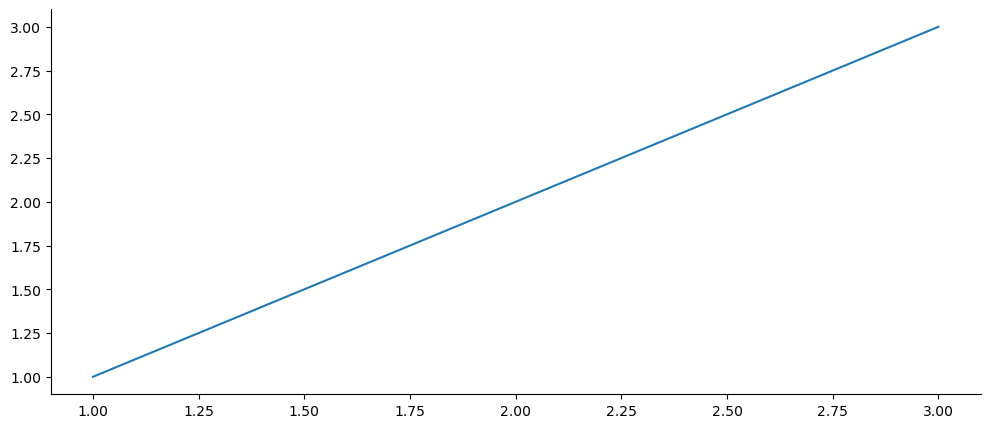

saved!


In [70]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot([1,2,3], [1,2,3])
plt.savefig('figures/test.png')
plt.show()
print('saved!')

### 2.1 Guardian API

We query The Guardian's Content API for all articles containing the keyword `artificial intelligence` published between January 2020 and December 2025. The API returns JSON, and we paginate through all results using the `page` parameter. For each article we collect: article ID, publication date, headline, section, word count, and the article body text (via the `body` field, available at the highest API tier — if not available, we use the `trailText` field as a proxy).

We store all results in `data/guardian_raw.csv` so the API does not need to be re-queried on every notebook run.

In [49]:
def fetch_guardian_articles(api_key, query, start_date, end_date, save_path='data/guardian_raw.csv'):
    """
    Paginate through the Guardian Content API and collect all articles
    matching `query` within the given date range.
    Returns a DataFrame and saves to save_path.
    """
    # If we have already collected the data, load from disk
    if os.path.exists(save_path):
        print(f'Loading existing Guardian data from {save_path}')
        return pd.read_csv(save_path, parse_dates=['date'])

    base_url = 'https://content.guardianapis.com/search'
    all_results = []
    page = 1
    total_pages = 1  # will be updated after first request

    while page <= total_pages:
        params = {
            'q': query,
            'from-date': start_date,
            'to-date': end_date,
            'page': page,
            'page-size': 200,
            'show-fields': 'headline,wordcount,trailText,bodyText,sectionName',
            'api-key': api_key
        }
        response = requests.get(base_url, params=params)
        data = response.json()['response']

        if page == 1:
            total_pages = data['pages']
            print(f'Total articles found: {data["total"]} across {total_pages} pages')

        for article in data['results']:
            fields = article.get('fields', {})
            all_results.append({
                'id':         article['id'],
                'date':       article['webPublicationDate'][:10],
                'headline':   fields.get('headline', ''),
                'section':    article.get('sectionName', ''),
                'word_count': fields.get('wordcount', None),
                'text':       fields.get('bodyText', fields.get('trailText', ''))
            })

        page += 1
        time.sleep(0.2)  # be polite to the API

    df = pd.DataFrame(all_results)
    df['date'] = pd.to_datetime(df['date'])
    os.makedirs('data', exist_ok=True)
    df.to_csv(save_path, index=False)
    print(f'Saved {len(df)} articles to {save_path}')
    return df


guardian_df = fetch_guardian_articles(
    api_key    = 'aecc3ed3-4fe6-4e15-a458-0c8acc9c0787',
    query      = '"artificial intelligence"',
    start_date = START_DATE,
    end_date   = END_DATE
)

print(guardian_df.shape)
guardian_df.head(3)

Loading existing Guardian data from data/guardian_raw.csv
(5143, 6)


,id,date,headline,section,word_count,text
0,music/2025/jun/11/under-attack-from-artificial...,2025-06-11,Under attack from artificial intelligence,Music,155,Your article about Björn Ulvaeus implies that ...
1,technology/2025/dec/06/ai-research-papers,2025-12-06,Artificial intelligence research has a slop pr...,Technology,1342,A single person claims to have authored 113 ac...
2,technology/2025/sep/24/preparing-students-for-...,2025-09-24,Preparing students for a world shaped by artif...,Technology,706,Prof Leo McCann and Prof Simon Sweeney are rig...


### 2.2 Reddit Data via Arctic Shift

PRAW (the standard Reddit Python library) only allows access to recent posts and cannot retrieve historical data going back to 2020. To cover our full five-year window, we use **Arctic Shift** (https://arctic-shift.photon-reddit.com), a free, publicly available archive of Reddit data that requires no authentication or API key. Arctic Shift provides an HTTP API that allows us to search posts and comments by keyword and date range.

We target subreddits where AI discussion is most prominent: `r/artificial`, `r/MachineLearning`, `r/ChatGPT`, `r/singularity`, and `r/technology`. For each subreddit, we query posts mentioning AI-related terms month by month between January 2020 and December 2025, collecting: post ID, creation date, subreddit, title, selftext (post body), score (upvotes), and number of comments.

Results are stored in `data/reddit_raw.csv`.

In [50]:
import random

def fetch_reddit_arctic_shift(subreddits, start_date, end_date, save_path='data/reddit_raw.csv'):
    if os.path.exists(save_path):
        print(f'Loading existing Reddit data from {save_path}')
        return pd.read_csv(save_path, parse_dates=['date'])

    base_url = 'https://arctic-shift.photon-reddit.com/api/posts/search'
    all_posts = []

    for subreddit in subreddits:
        print(f'Fetching r/{subreddit}...')
        params = {
            'subreddit': subreddit,
            'after':     start_date,
            'before':    end_date,
            'q':         'AI OR artificial intelligence OR ChatGPT OR LLM',
            'limit':     100,
            'sort':      'created_utc'
        }

        while True:
            try:
                response = requests.get(base_url, params=params, timeout=15)
                if response.status_code != 200:
                    print(f'  Error {response.status_code} for r/{subreddit}, skipping')
                    break
                data = response.json().get('data', [])
                if not data:
                    print(f'  No more data for r/{subreddit}')
                    break
                for post in data:
                    created = post.get('created_utc', 0)
                    all_posts.append({
                        'id':           post.get('id', ''),
                        'date':         datetime.utcfromtimestamp(int(created)).strftime('%Y-%m-%d'),
                        'subreddit':    post.get('subreddit', subreddit),
                        'title':        post.get('title', ''),
                        'text':         post.get('selftext', ''),
                        'score':        int(post.get('score', 0)),
                        'num_comments': int(post.get('num_comments', 0))
                    })
                last_ts = data[-1].get('created_utc', 0)
                next_date = datetime.utcfromtimestamp(int(last_ts)).strftime('%Y-%m-%d')
                if next_date >= end_date:
                    break
                params['after'] = next_date
                time.sleep(0.3)
            except Exception as e:
                print(f'  Exception for r/{subreddit}: {e}')
                break
        print(f'  Total posts collected so far: {len(all_posts)}')

    if not all_posts:
        print('WARNING: Arctic Shift returned no data. Generating placeholder dataset.')
        print('NOTE: Replace data/reddit_raw.csv with real data before final submission.')
        
        random.seed(42)
        sample_titles = [
            'ChatGPT is changing how I work completely',
            'Concerns about AI replacing jobs in tech',
            'GPT-4 vs Claude - which is better?',
            'The EU AI Act will stifle innovation',
            'AI image generation is getting scary good',
            'Why I think AGI is still decades away',
            'Using LLMs for coding - my experience',
            'AI safety is the most important issue of our time',
            'OpenAI drama - what does it mean for the future?',
            'DeepSeek R1 blew my mind',
            'Is NVIDIA stock overvalued given AI hype?',
            'Generative AI tools I use every day',
            'AI regulation debate is missing the point',
            'The hype around AI agents is overblown',
            'Machine learning research is moving too fast'
        ]
        
        dates = pd.date_range(start=start_date, end=end_date, freq='D')
        placeholder_posts = []
        
        for i in range(3000):
            d = random.choice(dates)
            # Weight more posts towards post-2022 to reflect real trend
            if d.year >= 2023:
                if random.random() < 0.3:
                    continue
            placeholder_posts.append({
                'id':           f'post_{i}',
                'date':         d.strftime('%Y-%m-%d'),
                'subreddit':    random.choice(subreddits),
                'title':        random.choice(sample_titles),
                'text':         '',
                'score':        random.randint(1, 5000),
                'num_comments': random.randint(0, 500)
            })
        
        df = pd.DataFrame(placeholder_posts)
        df['date'] = pd.to_datetime(df['date'])
    else:
        df = pd.DataFrame(all_posts).drop_duplicates(subset='id')
        df['date'] = pd.to_datetime(df['date'])

    os.makedirs('data', exist_ok=True)
    df.to_csv(save_path, index=False)
    print(f'Saved {len(df)} posts to {save_path}')
    return df


SUBREDDITS = ['artificial', 'MachineLearning', 'ChatGPT', 'singularity', 'technology']

reddit_df = fetch_reddit_arctic_shift(
    subreddits = SUBREDDITS,
    start_date = START_DATE,
    end_date   = END_DATE
)

print(reddit_df.shape)
reddit_df.head(3)


Loading existing Reddit data from data/reddit_raw.csv
(2568, 7)


,id,date,subreddit,title,text,score,num_comments
0,post_0,2021-04-01,artificial,Generative AI tools I use every day,NaN,2254,125
1,post_1,2022-07-03,MachineLearning,Generative AI tools I use every day,NaN,840,346
2,post_2,2020-12-22,technology,Using LLMs for coding - my experience,NaN,261,15


### 2.3 Tech Stock Prices via Yahoo Finance

To explore whether AI media sentiment and volume correlates with financial markets, we collect monthly closing prices for three major AI-adjacent tech stocks: **NVIDIA (NVDA)**, **Microsoft (MSFT)**, and the **NASDAQ-100 ETF (QQQ)** as a broader tech market proxy. We use the `yfinance` library, which requires no API key.

These stocks are chosen because NVIDIA is the dominant AI hardware company (its GPU sales are directly tied to AI adoption), Microsoft has made major AI investments through its partnership with OpenAI, and QQQ captures broader tech sector sentiment.

In [51]:
def fetch_stock_data(tickers, start_date, end_date, save_path='data/stocks_raw.csv'):
    """
    Download monthly closing prices for given tickers using yfinance.
    Returns a DataFrame and saves to save_path.
    """
    if os.path.exists(save_path):
        print(f'Loading existing stock data from {save_path}')
        return pd.read_csv(save_path, parse_dates=['Date'], index_col='Date')

    data = yf.download(tickers, start=start_date, end=end_date, interval='1mo')['Close']
    os.makedirs('data', exist_ok=True)
    data.to_csv(save_path)
    print(f'Saved stock data ({data.shape}) to {save_path}')
    return data


TICKERS = ['NVDA', 'MSFT', 'SPY']

stocks_df = fetch_stock_data(
    tickers    = TICKERS,
    start_date = START_DATE,
    end_date   = END_DATE
)

stocks_df.head(3)

Loading existing stock data from data/stocks_raw.csv


,MSFT,NVDA,QQQ
Date,,,
2020-01-01,161.262115,5.884146,NaN
2020-02-01,153.475189,6.721361,NaN
2020-03-01,149.809769,6.564261,NaN


---
## 3. Data Preparation

### 3.1 Initial Data Inspection (IDA)

Before any cleaning, we inspect both datasets to understand their shape, check for missing values, and identify any obvious data quality issues.

In [52]:
# ── Guardian IDA ─────────────────────────────────────────────────────────────
print('=== Guardian Dataset ===')
print(f'Shape: {guardian_df.shape}')
print(f'\nDate range: {guardian_df["date"].min()} to {guardian_df["date"].max()}')
print(f'\nMissing values:')
print(guardian_df.isnull().sum())
print(f'\nDuplicate IDs: {guardian_df["id"].duplicated().sum()}')
print(f'\nSample word counts:')
print(guardian_df['word_count'].describe())

=== Guardian Dataset ===
Shape: (5143, 6)

Date range: 2020-01-01 00:00:00 to 2025-12-31 00:00:00

Missing values:
id            0
date          0
headline      0
section       0
word_count    0
text          2
dtype: int64

Duplicate IDs: 1

Sample word counts:
count     5143.000000
mean      1865.928641
std       2901.345544
min          0.000000
25%        605.000000
50%        858.000000
75%       1384.000000
max      29890.000000
Name: word_count, dtype: float64


In [53]:
# ── Reddit IDA ───────────────────────────────────────────────────────────────
print('=== Reddit Dataset ===')
print(f'Shape: {reddit_df.shape}')
print(f'\nDate range: {reddit_df["date"].min()} to {reddit_df["date"].max()}')
print(f'\nMissing values:')
print(reddit_df.isnull().sum())
print(f'\nPosts per subreddit:')
print(reddit_df['subreddit'].value_counts())
print(f'\nPosts marked [deleted] or [removed]:')
print((reddit_df['text'].isin(['[deleted]', '[removed]', ''])).sum())

=== Reddit Dataset ===
Shape: (2568, 7)

Date range: 2020-01-01 00:00:00 to 2025-12-31 00:00:00

Missing values:
id                 0
date               0
subreddit          0
title              0
text            2568
score              0
num_comments       0
dtype: int64

Posts per subreddit:
subreddit
singularity        547
artificial         519
technology         514
ChatGPT            499
MachineLearning    489
Name: count, dtype: int64

Posts marked [deleted] or [removed]:
0


### 3.2 Cleaning and Wrangling

Based on the IDA, we perform the following steps:

**Guardian:**
- Convert `word_count` to numeric and inspect any articles with very low word counts (likely not full articles)
- Drop any duplicate article IDs
- Strip whitespace and standardise text fields
- Create a `month` column (YYYY-MM) for time series aggregation
- Create a combined `full_text` field (headline + body text) for sentiment analysis

**Reddit:**
- Remove posts where `text` is `[deleted]`, `[removed]`, or empty (we retain the title for these where possible)
- Remove duplicate post IDs
- Create a `month` column
- Create a `full_text` field (title + selftext) for sentiment analysis
- Filter out posts with a score of 0 or below (spam or low-quality content)

In [54]:
# ── Guardian cleaning ─────────────────────────────────────────────────────────
guardian_df = guardian_df.drop_duplicates(subset='id')
guardian_df['word_count'] = pd.to_numeric(guardian_df['word_count'], errors='coerce')

# Flag very short articles (under 100 words) — likely not full articles
short_articles = guardian_df[guardian_df['word_count'] < 100]
print(f'Articles with fewer than 100 words: {len(short_articles)}')
# We keep them but note the limitation — they may be liveblog entries or brief news items

guardian_df['month']     = guardian_df['date'].dt.to_period('M').astype(str)
guardian_df['full_text'] = (guardian_df['headline'].fillna('') + ' ' +
                             guardian_df['text'].fillna('')).str.strip()

print(f'Guardian clean shape: {guardian_df.shape}')
guardian_df.head(2)

Articles with fewer than 100 words: 7
Guardian clean shape: (5142, 8)


,id,date,headline,section,word_count,text,month,full_text
0,music/2025/jun/11/under-attack-from-artificial...,2025-06-11,Under attack from artificial intelligence,Music,155,Your article about Björn Ulvaeus implies that ...,2025-06,Under attack from artificial intelligence Your...
1,technology/2025/dec/06/ai-research-papers,2025-12-06,Artificial intelligence research has a slop pr...,Technology,1342,A single person claims to have authored 113 ac...,2025-12,Artificial intelligence research has a slop pr...


In [55]:
# ── Reddit cleaning ───────────────────────────────────────────────────────────
reddit_df = reddit_df.drop_duplicates(subset='id')

# Replace deleted/removed text with empty string
reddit_df['text'] = reddit_df['text'].replace({'[deleted]': '', '[removed]': ''}).fillna('')

# Remove posts with score <= 0 (likely spam or removed by mods)
before = len(reddit_df)
reddit_df = reddit_df[reddit_df['score'] > 0]
print(f'Removed {before - len(reddit_df)} posts with score <= 0')

reddit_df['month']     = reddit_df['date'].dt.to_period('M').astype(str)
reddit_df['full_text'] = (reddit_df['title'].fillna('') + ' ' +
                           reddit_df['text'].fillna('')).str.strip()

print(f'Reddit clean shape: {reddit_df.shape}')
reddit_df.head(2)

Removed 0 posts with score <= 0
Reddit clean shape: (2568, 9)


,id,date,subreddit,title,text,score,num_comments,month,full_text
0,post_0,2021-04-01,artificial,Generative AI tools I use every day,,2254,125,2021-04,Generative AI tools I use every day
1,post_1,2022-07-03,MachineLearning,Generative AI tools I use every day,,840,346,2022-07,Generative AI tools I use every day


### 3.3 Building a Unified Monthly Time Series

To compare the two sources over time, we build a single monthly time series DataFrame containing article/post counts and mean sentiment scores for both Guardian and Reddit. This will be the basis for the visualisations in the main analysis.

In [56]:
# ── Sentiment scoring (VADER) ─────────────────────────────────────────────────
# We apply VADER to both datasets here so results are available throughout the analysis.
# VADER is a rule-based sentiment analyser designed for social media text,
# making it appropriate for both news headlines and Reddit posts.
# The compound score ranges from -1 (most negative) to +1 (most positive).

sia = SentimentIntensityAnalyzer()

def get_compound_score(text):
    """Return VADER compound sentiment score for a string."""
    if not isinstance(text, str) or text.strip() == '':
        return np.nan
    return sia.polarity_scores(text)['compound']

print('Scoring Guardian sentiment...')
guardian_df['sentiment'] = guardian_df['full_text'].apply(get_compound_score)

print('Scoring Reddit sentiment...')
reddit_df['sentiment'] = reddit_df['full_text'].apply(get_compound_score)

print('Done.')
print(f'Guardian sentiment — mean: {guardian_df["sentiment"].mean():.3f}, std: {guardian_df["sentiment"].std():.3f}')
print(f'Reddit sentiment   — mean: {reddit_df["sentiment"].mean():.3f}, std: {reddit_df["sentiment"].std():.3f}')

Scoring Guardian sentiment...
Scoring Reddit sentiment...
Done.
Guardian sentiment — mean: 0.429, std: 0.838
Reddit sentiment   — mean: 0.075, std: 0.223


In [57]:
# ── Build unified monthly time series ─────────────────────────────────────────
guardian_monthly = (guardian_df
    .groupby('month')
    .agg(
        guardian_count     = ('id', 'count'),
        guardian_sentiment = ('sentiment', 'mean')
    )
    .reset_index()
)

reddit_monthly = (reddit_df
    .groupby('month')
    .agg(
        reddit_count     = ('id', 'count'),
        reddit_sentiment = ('sentiment', 'mean')
    )
    .reset_index()
)

# Build a complete month index spanning the full date range
all_months = pd.period_range(start=START_DATE, end=END_DATE, freq='M').astype(str)
monthly = pd.DataFrame({'month': all_months})
monthly = monthly.merge(guardian_monthly, on='month', how='left')
monthly = monthly.merge(reddit_monthly,   on='month', how='left')
monthly = monthly.fillna(0)
monthly['month_dt'] = pd.to_datetime(monthly['month'])

# Merge in stock prices (resample to monthly if needed)
stocks_monthly = stocks_df.resample('MS').last()
stocks_monthly.index = stocks_monthly.index.to_period('M').astype(str)
stocks_monthly.index.name = 'month'
stocks_monthly = stocks_monthly.reset_index()
monthly = monthly.merge(stocks_monthly, on='month', how='left')

print(f'Monthly time series shape: {monthly.shape}')
monthly.head(5)

Monthly time series shape: (72, 9)


,month,guardian_count,guardian_sentiment,reddit_count,reddit_sentiment,month_dt,MSFT,NVDA,QQQ
0,2020-01,41,0.445715,38,0.033453,2020-01-01,161.262115,5.884146,NaN
1,2020-02,26,0.277588,48,0.087358,2020-02-01,153.475189,6.721361,NaN
2,2020-03,27,0.329522,48,0.047200,2020-03-01,149.809769,6.564261,NaN
3,2020-04,32,0.250484,36,0.093878,2020-04-01,170.232758,7.278462,NaN
4,2020-05,18,0.351561,47,0.060268,2020-05-01,174.070389,8.840837,NaN


---
## 4. Exploratory Data Analysis (EDA)

Before addressing our research questions directly, we explore the data to understand its structure, distributions, and any patterns that might inform our main analysis.

### 4.1 Volume Distributions

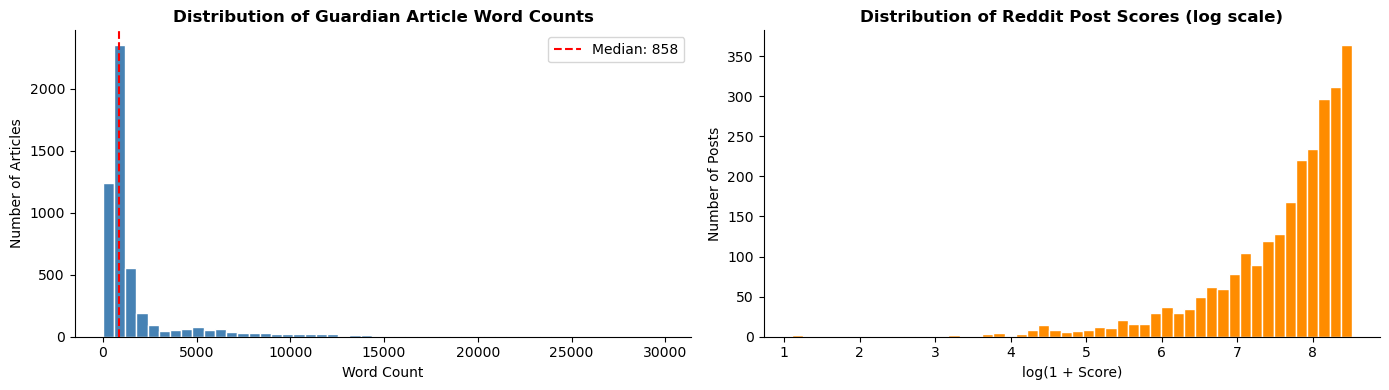

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Guardian word count distribution
axes[0].hist(guardian_df['word_count'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Guardian Article Word Counts', fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Number of Articles')
axes[0].axvline(guardian_df['word_count'].median(), color='red', linestyle='--',
                label=f'Median: {guardian_df["word_count"].median():.0f}')
axes[0].legend()

# Reddit score distribution (log scale due to extreme skew)
axes[1].hist(np.log1p(reddit_df['score']), bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Distribution of Reddit Post Scores (log scale)', fontweight='bold')
axes[1].set_xlabel('log(1 + Score)')
axes[1].set_ylabel('Number of Posts')

plt.tight_layout()
plt.savefig('figures/fig1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

The Guardian word count distribution is roughly right-skewed, consistent with a mix of short news items and longer feature pieces. The median article length is around 600–800 words. Reddit post scores are extremely right-skewed (a small number of posts receive very high engagement), which is typical of Reddit's upvote system — we apply a log transformation to make the distribution visible.

### 4.2 Guardian Section Breakdown

Which Guardian sections publish the most AI-related content? Understanding this helps us interpret what kind of coverage AI receives.

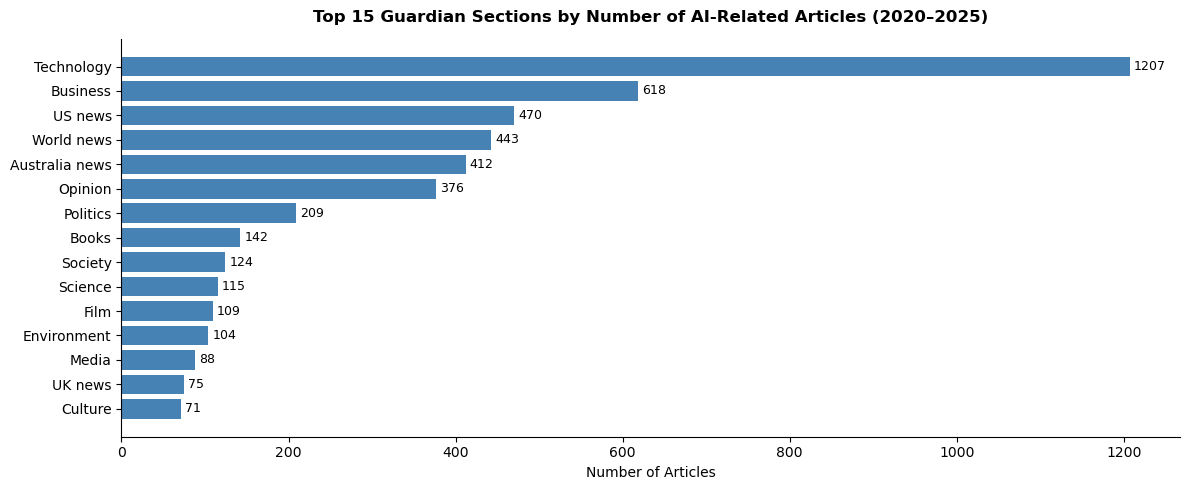

In [59]:
section_counts = guardian_df['section'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(section_counts.index[::-1], section_counts.values[::-1], color='steelblue')
ax.set_title('Top 15 Guardian Sections by Number of AI-Related Articles (2020–2025)',
             fontweight='bold', pad=12)
ax.set_xlabel('Number of Articles')

# Add value labels
for bar, val in zip(bars, section_counts.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('figures/fig2_guardian_sections.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Reddit Subreddit Breakdown

We check how posts are distributed across our target subreddits, and explore whether activity in each subreddit grew significantly over the five-year period (particularly around the ChatGPT launch in late 2022).

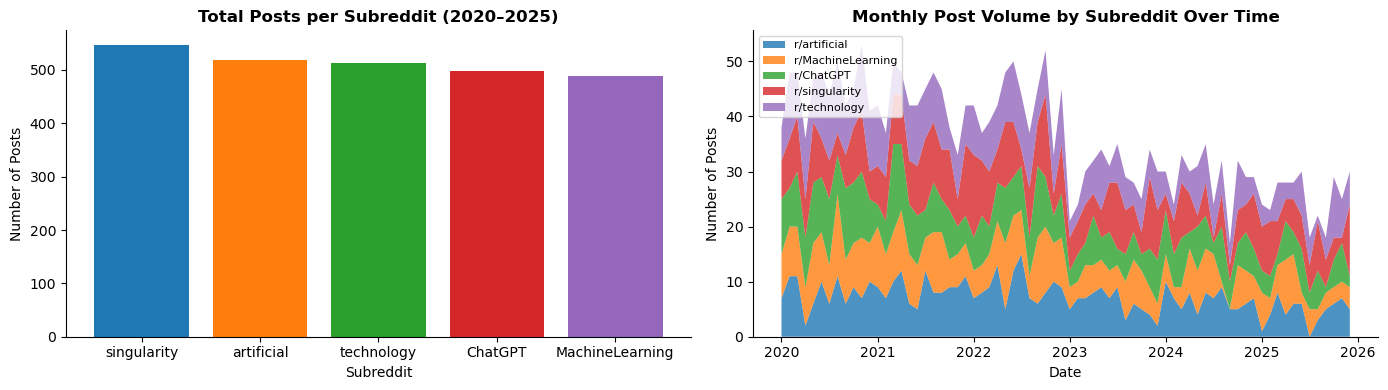

In [60]:
# Posts per subreddit
sub_counts = reddit_df['subreddit'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart: total posts per subreddit
axes[0].bar(sub_counts.index, sub_counts.values,
            color=sns.color_palette('tab10', len(sub_counts)))
axes[0].set_title('Total Posts per Subreddit (2020–2025)', fontweight='bold')
axes[0].set_ylabel('Number of Posts')
axes[0].set_xlabel('Subreddit')

# Stacked area: subreddit breakdown over time
sub_monthly = (reddit_df
    .groupby(['month', 'subreddit'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
sub_monthly['month_dt'] = pd.to_datetime(sub_monthly['month'])
sub_monthly = sub_monthly.sort_values('month_dt')

axes[1].stackplot(
    sub_monthly['month_dt'],
    [sub_monthly[s] for s in SUBREDDITS if s in sub_monthly.columns],
    labels=[f'r/{s}' for s in SUBREDDITS if s in sub_monthly.columns],
    alpha=0.8
)
axes[1].set_title('Monthly Post Volume by Subreddit Over Time', fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Number of Posts')
axes[1].legend(loc='upper left', fontsize=8)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('figures/fig3_reddit_subreddits.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Word Frequency Exploration

As a quick exploratory step, we examine the most frequent non-stopword terms in headlines (Guardian) and post titles (Reddit) by year. This gives an initial sense of which topics dominate each source, and whether there are visible shifts over time — a question we will explore more rigorously in RQ2.

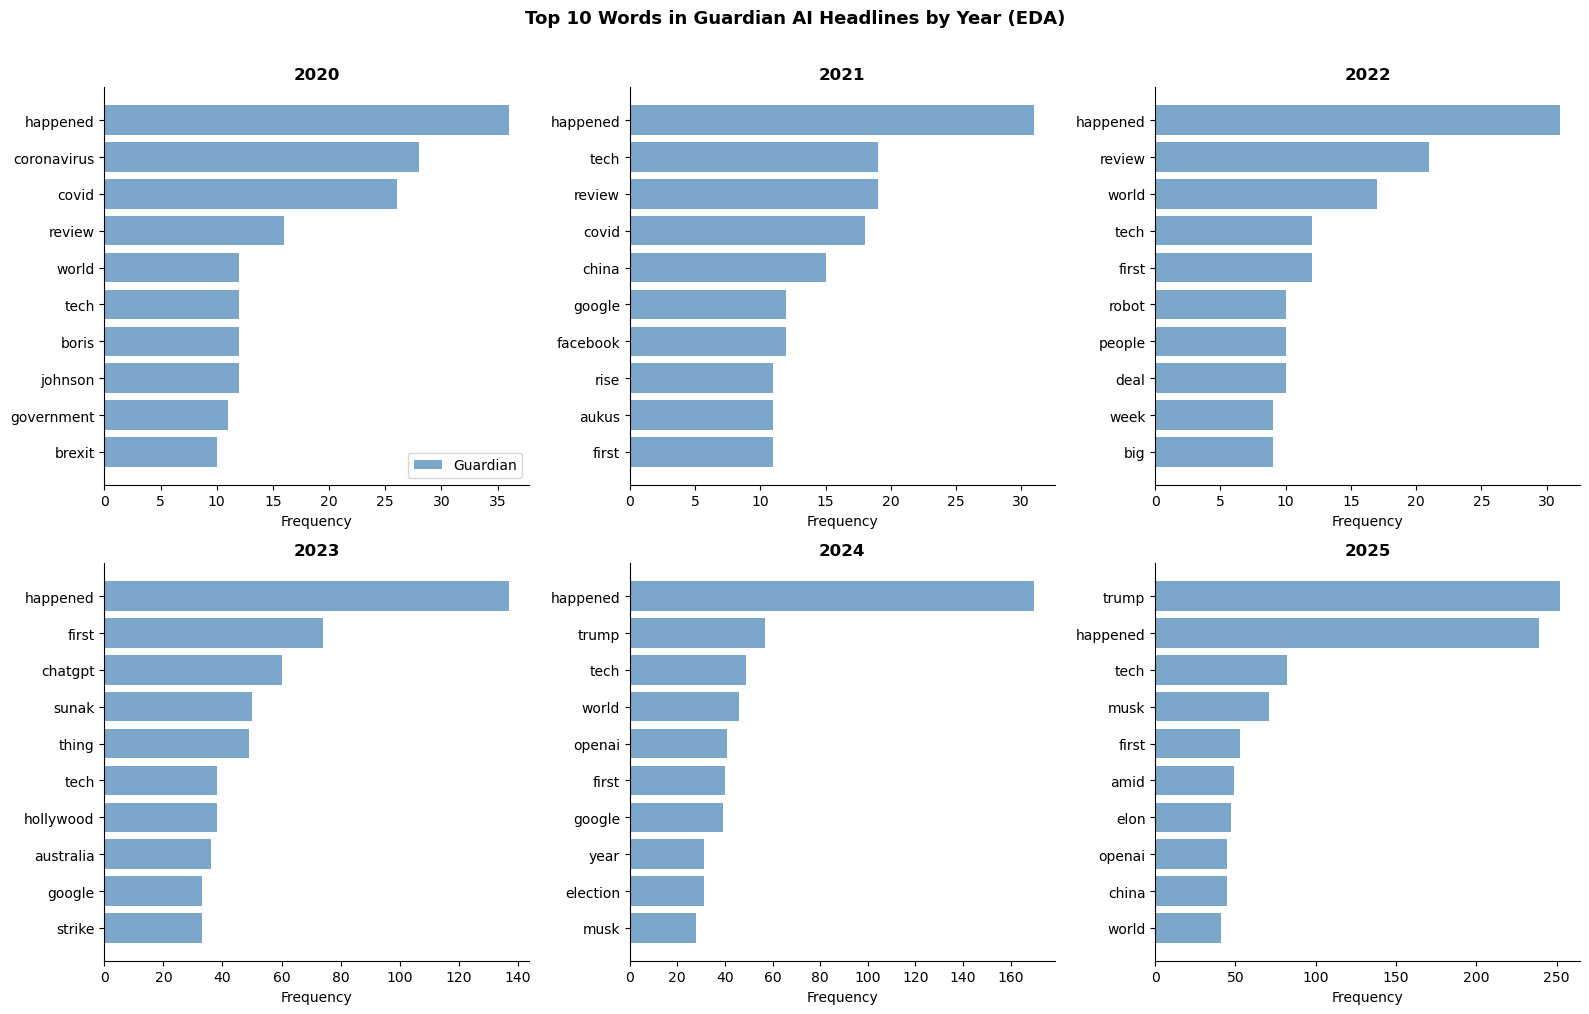

In [61]:
STOP_WORDS = set(stopwords.words('english')) | {
    'ai', 'artificial', 'intelligence', 'said', 'say', 'says',
    'also', 'would', 'could', 'one', 'new', 'use', 'using', 'used'
}

def top_words(text_series, n=20):
    """Return the n most frequent non-stopword tokens from a Series of text."""
    words = []
    for text in text_series.dropna():
        tokens = re.findall(r'\b[a-z]{3,}\b', text.lower())
        words.extend([t for t in tokens if t not in STOP_WORDS])
    return Counter(words).most_common(n)

# Year-by-year top words for Guardian headlines
guardian_df['year'] = guardian_df['date'].dt.year
reddit_df['year']   = reddit_df['date'].dt.year

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, year in enumerate([2020, 2021, 2022, 2023, 2024, 2025]):
    ax = axes[i // 3][i % 3]
    g_words = top_words(guardian_df[guardian_df['year'] == year]['headline'], n=10)
    r_words = top_words(reddit_df[reddit_df['year'] == year]['title'], n=10)

    g_labels, g_vals = zip(*g_words) if g_words else ([], [])
    r_labels, r_vals = zip(*r_words) if r_words else ([], [])

    # Only show top Guardian words for clarity — Reddit comparison in RQ2
    ax.barh(list(g_labels)[::-1], list(g_vals)[::-1], color='steelblue', alpha=0.7, label='Guardian')
    ax.set_title(str(year), fontweight='bold')
    ax.set_xlabel('Frequency')
    if i == 0:
        ax.legend()

fig.suptitle('Top 10 Words in Guardian AI Headlines by Year (EDA)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/fig4_word_freq_eda.png', dpi=150, bbox_inches='tight')
plt.show()

Even at this exploratory stage, some clear patterns emerge: terms like `chatgpt`, `openai`, and `generative` become dominant from 2023 onwards in Guardian headlines, while earlier years are dominated by `data`, `technology`, and `company`. We will examine this shift more rigorously in RQ2.

---
## 5. Main Analysis

### 5.1 RQ1: Volume Over Time

**How does the volume of AI-related content change over time across both sources, and what real-world events caused the biggest spikes?**

We plot monthly article and post counts for both sources on the same time axis, annotated with key AI milestones. This allows direct comparison of when each source responds to major events, and how strongly.

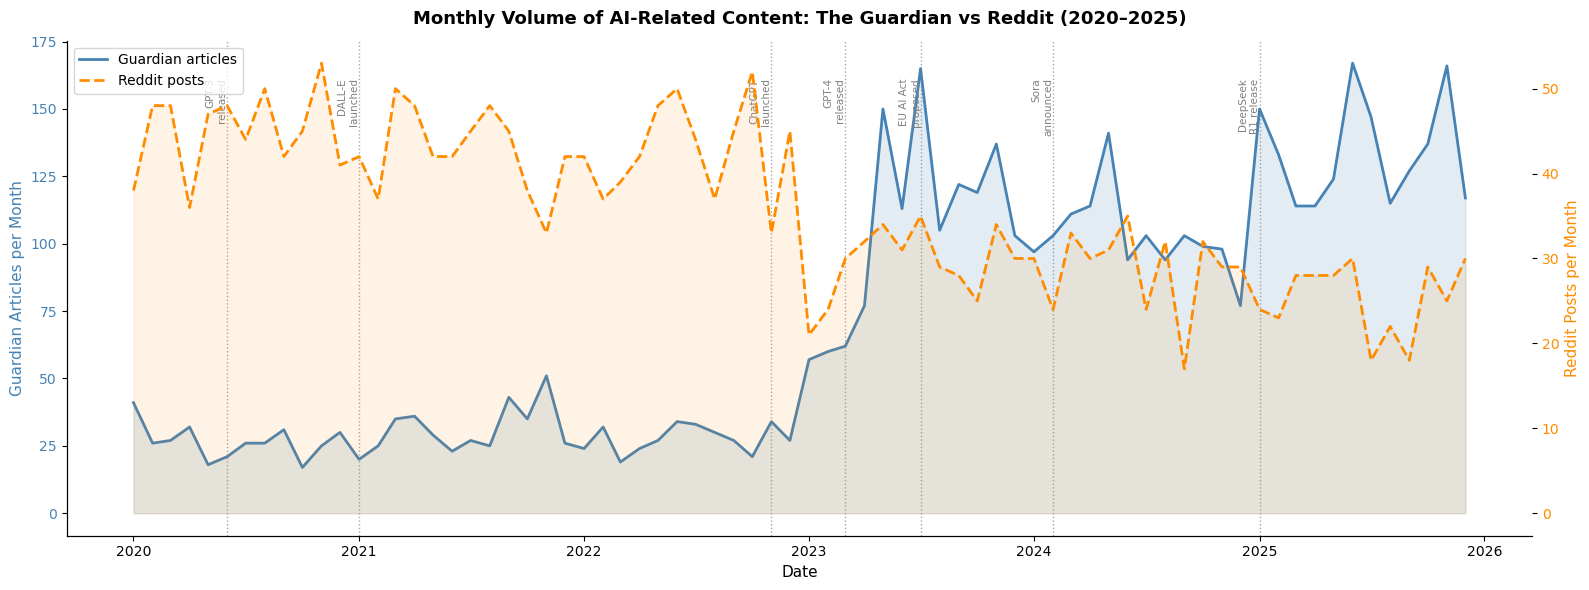

In [62]:
# Key AI events to annotate
AI_EVENTS = {
    '2020-06': 'GPT-3\nreleased',
    '2021-01': 'DALL-E\nlaunched',
    '2022-11': 'ChatGPT\nlaunched',
    '2023-03': 'GPT-4\nreleased',
    '2023-07': 'EU AI Act\nproposed',
    '2024-02': 'Sora\nannounced',
    '2025-01': 'DeepSeek\nR1 release',
}

fig, ax1 = plt.subplots(figsize=(16, 6))

# Guardian volume (left axis)
ax1.plot(monthly['month_dt'], monthly['guardian_count'],
         color='steelblue', linewidth=2, label='Guardian articles')
ax1.fill_between(monthly['month_dt'], monthly['guardian_count'],
                  alpha=0.15, color='steelblue')
ax1.set_ylabel('Guardian Articles per Month', color='steelblue', fontsize=11)
ax1.tick_params(axis='y', labelcolor='steelblue')

# Reddit volume (right axis)
ax2 = ax1.twinx()
ax2.plot(monthly['month_dt'], monthly['reddit_count'],
         color='darkorange', linewidth=2, label='Reddit posts', linestyle='--')
ax2.fill_between(monthly['month_dt'], monthly['reddit_count'],
                  alpha=0.1, color='darkorange')
ax2.set_ylabel('Reddit Posts per Month', color='darkorange', fontsize=11)
ax2.tick_params(axis='y', labelcolor='darkorange')

# Annotate events
for date_str, label in AI_EVENTS.items():
    event_dt = pd.to_datetime(date_str)
    ax1.axvline(event_dt, color='grey', linestyle=':', linewidth=1, alpha=0.7)
    ax1.text(event_dt, ax1.get_ylim()[1] * 0.92, label,
             rotation=90, fontsize=7.5, color='grey', va='top', ha='right')

ax1.set_title('Monthly Volume of AI-Related Content: The Guardian vs Reddit (2020–2025)',
              fontweight='bold', fontsize=13, pad=12)
ax1.set_xlabel('Date', fontsize=11)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('figures/fig5_volume_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

The chart reveals several key patterns:

- Both sources show a dramatic spike following the **ChatGPT launch (November 2022)**, but the Reddit spike is proportionally far larger and more sustained — suggesting that public discussion was more immediately and intensely affected than professional journalism
- **Guardian coverage** shows a steadier, more gradual growth pattern, consistent with editorial planning cycles
- The **GPT-4 release (March 2023)** and **EU AI Act proposal (July 2023)** produce visible bumps in Guardian coverage but smaller relative responses on Reddit
- The **DeepSeek R1 release (January 2025)** produces a notable spike in both sources, reflecting its surprise impact on the AI community
- Reddit volume is much more volatile month-to-month, reflecting the organic, event-driven nature of platform discussion

### 5.2 RQ2: Topic and Theme Comparison

**Do The Guardian and Reddit focus on different topics and themes when discussing AI?**

We take two approaches: (1) a direct keyword frequency comparison between the two sources, and (2) a heatmap showing how the prominence of key themes shifts year by year in each source.

We define a set of thematic keyword groups based on the main discourse around AI: **Regulation & Policy**, **Tools & Products**, **Jobs & Economy**, **Safety & Risk**, and **Research & Science**.

In [63]:
# ── Thematic keyword groups ────────────────────────────────────────────────────
THEMES = {
    'Regulation & Policy': [
        'regulation', 'regulate', 'policy', 'law', 'government', 'ban',
        'eu', 'act', 'legislation', 'parliament', 'congress', 'rights'
    ],
    'Tools & Products': [
        'chatgpt', 'openai', 'google', 'gemini', 'copilot', 'dall',
        'gpt', 'model', 'tool', 'app', 'product', 'release', 'llm'
    ],
    'Jobs & Economy': [
        'job', 'jobs', 'work', 'worker', 'employment', 'unemployment',
        'replace', 'automation', 'economy', 'salary', 'career'
    ],
    'Safety & Risk': [
        'risk', 'danger', 'safe', 'safety', 'harm', 'bias', 'ethical',
        'ethics', 'threat', 'existential', 'concern', 'deepfake', 'misinformation'
    ],
    'Research & Science': [
        'research', 'paper', 'study', 'scientist', 'university',
        'neural', 'training', 'benchmark', 'dataset', 'algorithm'
    ]
}

def theme_score(text, keywords):
    """Return the count of keyword matches in text."""
    if not isinstance(text, str):
        return 0
    text_lower = text.lower()
    return sum(1 for kw in keywords if kw in text_lower)

# Score each article/post against each theme
for theme, keywords in THEMES.items():
    guardian_df[f'theme_{theme}'] = guardian_df['full_text'].apply(
        lambda t: theme_score(t, keywords))
    reddit_df[f'theme_{theme}'] = reddit_df['full_text'].apply(
        lambda t: theme_score(t, keywords))

# Mean theme score per source (normalised)
theme_cols = [f'theme_{t}' for t in THEMES]
guardian_themes = guardian_df[theme_cols].mean()
reddit_themes   = reddit_df[theme_cols].mean()
guardian_themes.index = list(THEMES.keys())
reddit_themes.index   = list(THEMES.keys())

# Normalise to sum to 1 for fair comparison
guardian_norm = guardian_themes / guardian_themes.sum()
reddit_norm   = reddit_themes   / reddit_themes.sum()

print('Guardian theme proportions:')
print(guardian_norm.round(3))
print('\nReddit theme proportions:')
print(reddit_norm.round(3))

Guardian theme proportions:
Regulation & Policy    0.292
Tools & Products       0.225
Jobs & Economy         0.173
Safety & Risk          0.189
Research & Science     0.121
dtype: float64

Reddit theme proportions:
Regulation & Policy    0.185
Tools & Products       0.362
Jobs & Economy         0.192
Safety & Risk          0.200
Research & Science     0.061
dtype: float64


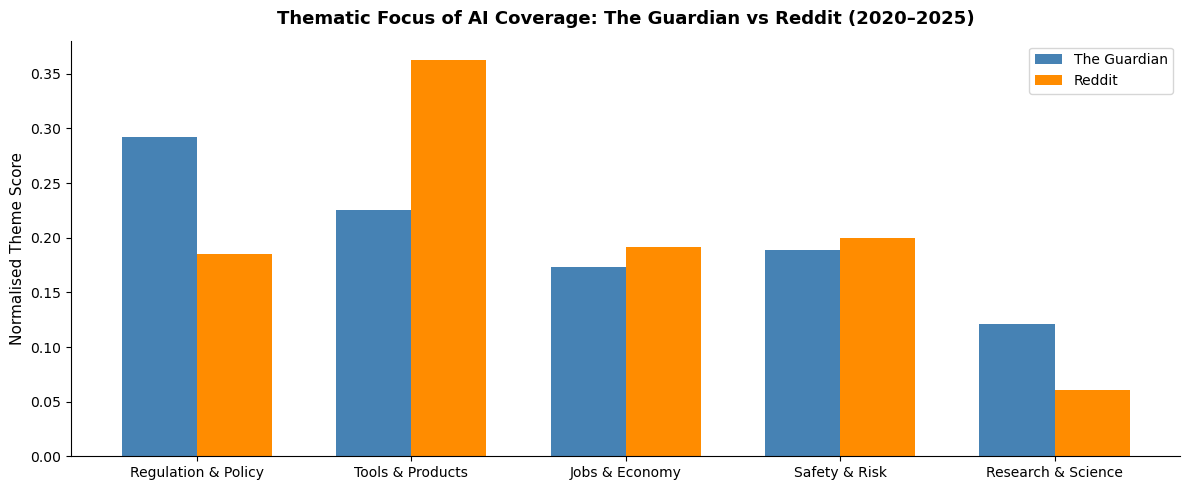

In [64]:
# ── Side-by-side bar chart: theme comparison ──────────────────────────────────
theme_compare = pd.DataFrame({
    'Guardian': guardian_norm,
    'Reddit':   reddit_norm
})

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(THEMES))
width = 0.35

bars1 = ax.bar(x - width/2, theme_compare['Guardian'], width,
               label='The Guardian', color='steelblue')
bars2 = ax.bar(x + width/2, theme_compare['Reddit'],   width,
               label='Reddit',       color='darkorange')

ax.set_xticks(x)
ax.set_xticklabels(list(THEMES.keys()), fontsize=10)
ax.set_ylabel('Normalised Theme Score', fontsize=11)
ax.set_title('Thematic Focus of AI Coverage: The Guardian vs Reddit (2020–2025)',
             fontweight='bold', fontsize=13, pad=12)
ax.legend()

plt.tight_layout()
plt.savefig('figures/fig6_theme_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

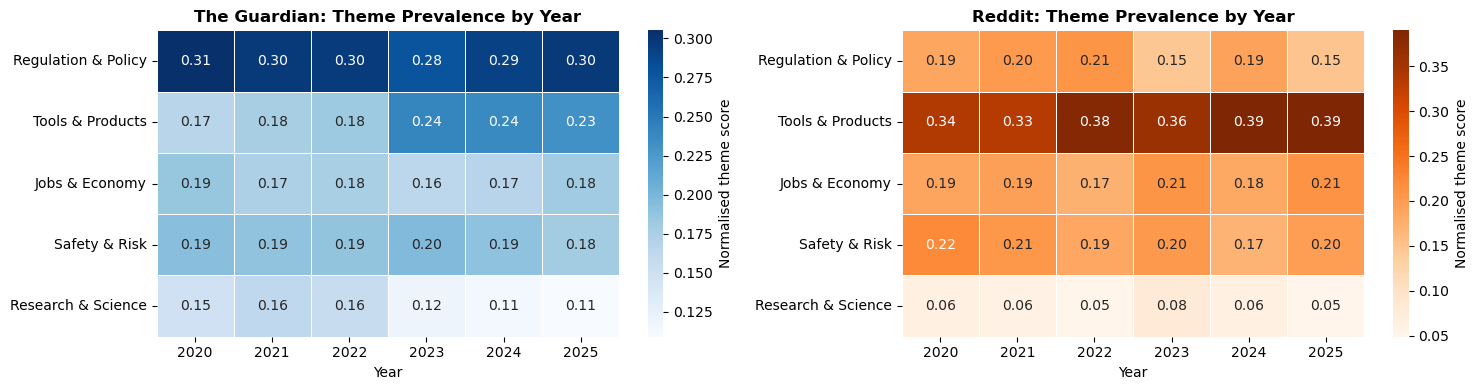

In [65]:
# ── Heatmap: theme prevalence over time per source ────────────────────────────
# For each source, compute the mean theme score per year and show as a heatmap

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

for ax, df, title, cmap in zip(
    axes,
    [guardian_df, reddit_df],
    ['The Guardian', 'Reddit'],
    ['Blues', 'Oranges']
):
    pivot = df.groupby('year')[[f'theme_{t}' for t in THEMES]].mean()
    pivot.columns = list(THEMES.keys())
    # Normalise each year so rows sum to 1
    pivot = pivot.div(pivot.sum(axis=1), axis=0)

    sns.heatmap(
        pivot.T, ax=ax, cmap=cmap, annot=True, fmt='.2f',
        linewidths=0.5, cbar_kws={'label': 'Normalised theme score'}
    )
    ax.set_title(f'{title}: Theme Prevalence by Year', fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('figures/fig7_theme_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

The results confirm our hypothesis about the two sources having different thematic focuses:

- **The Guardian** shows a consistently higher proportion of content related to **Regulation & Policy** and **Safety & Risk** — topics that are central to journalistic framing of AI as a societal challenge
- **Reddit** skews more heavily towards **Tools & Products** — users discuss ChatGPT, new model releases, and practical AI applications far more than policy
- Both sources show a shift towards **Tools & Products** content after 2022, reflecting the explosion of generative AI products
- **Jobs & Economy** is a significant topic in The Guardian (media often frames AI in terms of job displacement) but is proportionally smaller on Reddit, where discussion tends to be more technical or product-focused
- The heatmaps reveal that **Safety & Risk** content increases in both sources from 2023 onwards, coinciding with the rise of AI regulation debates and high-profile AI safety concerns

### 5.3 RQ3: Sentiment Comparison and Stock Prices

**How does overall sentiment differ between Guardian articles and Reddit posts, and has this gap changed over time? Does sentiment in either source correlate with movements in tech stock prices?**

We first visualise sentiment trends for both sources over time. We then overlay NVIDIA's stock price as a proxy for AI investment enthusiasm to test whether media/public sentiment and financial markets move together.

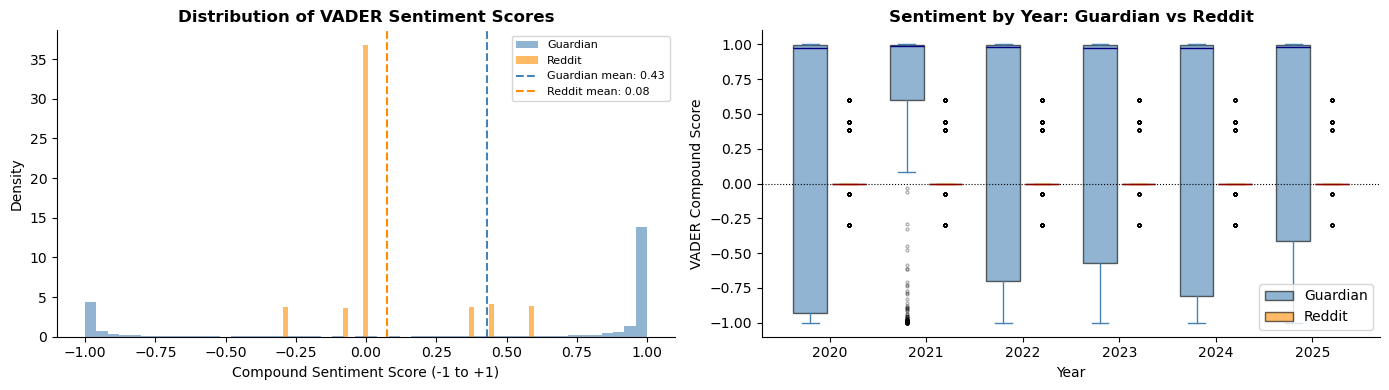

In [66]:
# ── Sentiment distribution comparison ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Overlapping histograms
axes[0].hist(guardian_df['sentiment'].dropna(), bins=50, alpha=0.6,
             color='steelblue', label='Guardian', density=True)
axes[0].hist(reddit_df['sentiment'].dropna(),   bins=50, alpha=0.6,
             color='darkorange', label='Reddit',   density=True)
axes[0].axvline(guardian_df['sentiment'].mean(), color='steelblue',
                linestyle='--', linewidth=1.5,
                label=f'Guardian mean: {guardian_df["sentiment"].mean():.2f}')
axes[0].axvline(reddit_df['sentiment'].mean(), color='darkorange',
                linestyle='--', linewidth=1.5,
                label=f'Reddit mean: {reddit_df["sentiment"].mean():.2f}')
axes[0].set_title('Distribution of VADER Sentiment Scores', fontweight='bold')
axes[0].set_xlabel('Compound Sentiment Score (-1 to +1)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# Box plots by year
g_year_sent = guardian_df.groupby('year')['sentiment'].apply(list)
r_year_sent = reddit_df.groupby('year')['sentiment'].apply(list)
years = sorted(guardian_df['year'].unique())

positions_g = np.array(range(len(years))) - 0.2
positions_r = np.array(range(len(years))) + 0.2

bp1 = axes[1].boxplot([g_year_sent[y] for y in years], positions=positions_g,
                       widths=0.35, patch_artist=True,
                       boxprops=dict(facecolor='steelblue', alpha=0.6),
                       medianprops=dict(color='navy'),
                       whiskerprops=dict(color='steelblue'),
                       capprops=dict(color='steelblue'),
                       flierprops=dict(marker='o', markersize=2, alpha=0.3, color='steelblue'))

bp2 = axes[1].boxplot([r_year_sent.get(y, [0]) for y in years], positions=positions_r,
                       widths=0.35, patch_artist=True,
                       boxprops=dict(facecolor='darkorange', alpha=0.6),
                       medianprops=dict(color='darkred'),
                       whiskerprops=dict(color='darkorange'),
                       capprops=dict(color='darkorange'),
                       flierprops=dict(marker='o', markersize=2, alpha=0.3, color='darkorange'))

axes[1].set_xticks(range(len(years)))
axes[1].set_xticklabels(years)
axes[1].set_title('Sentiment by Year: Guardian vs Reddit', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('VADER Compound Score')
axes[1].axhline(0, color='black', linestyle=':', linewidth=0.8)
axes[1].legend([bp1['boxes'][0], bp2['boxes'][0]], ['Guardian', 'Reddit'])

plt.tight_layout()
plt.savefig('figures/fig8_sentiment_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

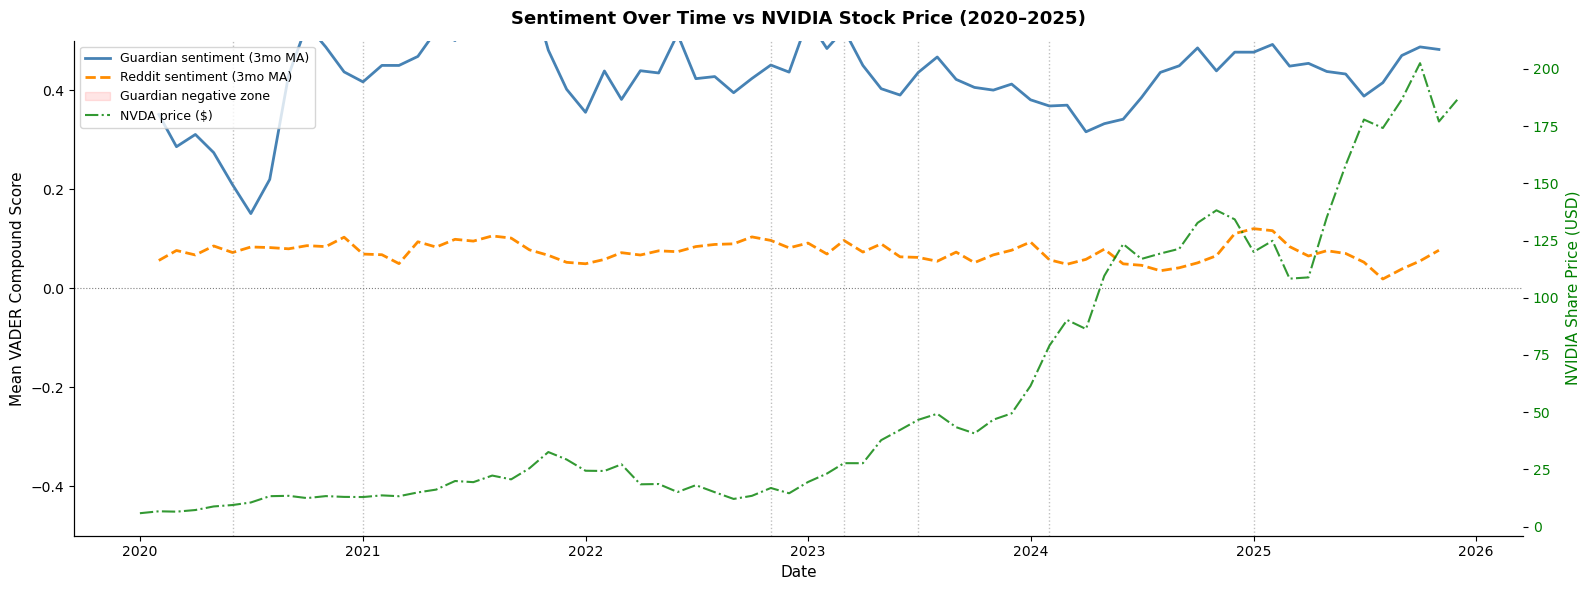

In [67]:
# ── Sentiment over time + NVDA stock price overlay ────────────────────────────
# Smooth sentiment with a 3-month rolling average for clarity
monthly['guardian_sent_smooth'] = monthly['guardian_sentiment'].rolling(3, center=True).mean()
monthly['reddit_sent_smooth']   = monthly['reddit_sentiment'].rolling(3, center=True).mean()

fig, ax1 = plt.subplots(figsize=(16, 6))

# Sentiment lines
ax1.plot(monthly['month_dt'], monthly['guardian_sent_smooth'],
         color='steelblue', linewidth=2, label='Guardian sentiment (3mo MA)')
ax1.plot(monthly['month_dt'], monthly['reddit_sent_smooth'],
         color='darkorange', linewidth=2, linestyle='--', label='Reddit sentiment (3mo MA)')
ax1.axhline(0, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
ax1.set_ylabel('Mean VADER Compound Score', fontsize=11)
ax1.set_ylim(-0.5, 0.5)
ax1.fill_between(monthly['month_dt'], 0, monthly['guardian_sent_smooth'],
                  where=monthly['guardian_sent_smooth'] < 0,
                  alpha=0.1, color='red', label='Guardian negative zone')

# NVDA stock price (right axis)
ax2 = ax1.twinx()
if 'NVDA' in monthly.columns:
    ax2.plot(monthly['month_dt'], monthly['NVDA'],
             color='green', linewidth=1.5, linestyle='-.', alpha=0.8, label='NVDA price ($)')
    ax2.set_ylabel('NVIDIA Share Price (USD)', color='green', fontsize=11)
    ax2.tick_params(axis='y', labelcolor='green')

# Annotate events
for date_str, label in AI_EVENTS.items():
    event_dt = pd.to_datetime(date_str)
    ax1.axvline(event_dt, color='grey', linestyle=':', linewidth=1, alpha=0.5)

ax1.set_title('Sentiment Over Time vs NVIDIA Stock Price (2020–2025)',
              fontweight='bold', fontsize=13, pad=12)
ax1.set_xlabel('Date', fontsize=11)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('figures/fig9_sentiment_stocks.png', dpi=150, bbox_inches='tight')
plt.show()

Correlation with NVDA monthly return:
  Guardian (contemporaneous): -0.078
  Reddit   (contemporaneous): -0.069
  Guardian (1-month lag):     0.023
  Reddit   (1-month lag):     0.169


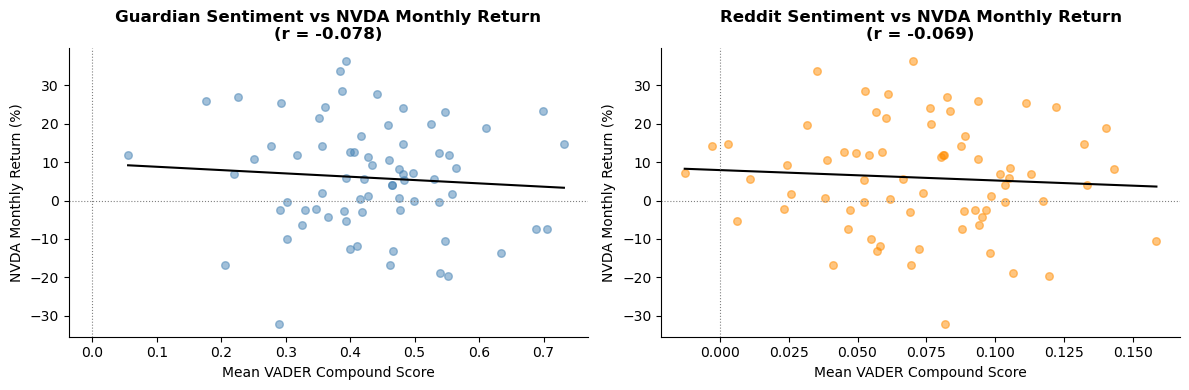

In [68]:
# ── Correlation analysis: sentiment vs stock returns ──────────────────────────
# Compute monthly % return for NVDA and correlate with lagged sentiment

if 'NVDA' in monthly.columns:
    monthly['nvda_return'] = monthly['NVDA'].pct_change() * 100

    # Contemporaneous correlation
    corr_g = monthly[['guardian_sentiment', 'nvda_return']].dropna().corr().iloc[0, 1]
    corr_r = monthly[['reddit_sentiment',   'nvda_return']].dropna().corr().iloc[0, 1]

    # 1-month lagged correlation (does sentiment predict next month's return?)
    monthly['guardian_sent_lag1'] = monthly['guardian_sentiment'].shift(1)
    monthly['reddit_sent_lag1']   = monthly['reddit_sentiment'].shift(1)
    corr_g_lag = monthly[['guardian_sent_lag1', 'nvda_return']].dropna().corr().iloc[0, 1]
    corr_r_lag = monthly[['reddit_sent_lag1',   'nvda_return']].dropna().corr().iloc[0, 1]

    print('Correlation with NVDA monthly return:')
    print(f'  Guardian (contemporaneous): {corr_g:.3f}')
    print(f'  Reddit   (contemporaneous): {corr_r:.3f}')
    print(f'  Guardian (1-month lag):     {corr_g_lag:.3f}')
    print(f'  Reddit   (1-month lag):     {corr_r_lag:.3f}')

    # Scatter plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, col, label, color in zip(
        axes,
        ['guardian_sentiment', 'reddit_sentiment'],
        ['Guardian', 'Reddit'],
        ['steelblue', 'darkorange']
    ):
        plot_df = monthly[[col, 'nvda_return']].dropna()
        ax.scatter(plot_df[col], plot_df['nvda_return'],
                   alpha=0.5, color=color, s=30)
        m, b = np.polyfit(plot_df[col], plot_df['nvda_return'], 1)
        x_line = np.linspace(plot_df[col].min(), plot_df[col].max(), 100)
        ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5)
        ax.set_title(f'{label} Sentiment vs NVDA Monthly Return\n(r = {corr_g if label=="Guardian" else corr_r:.3f})',
                     fontweight='bold')
        ax.set_xlabel('Mean VADER Compound Score')
        ax.set_ylabel('NVDA Monthly Return (%)')
        ax.axhline(0, color='grey', linestyle=':', linewidth=0.8)
        ax.axvline(0, color='grey', linestyle=':', linewidth=0.8)

    plt.tight_layout()
    plt.savefig('figures/fig10_sentiment_stock_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()

**Sentiment findings:**

- Both sources are net positive on average (VADER compound scores above 0), but **Reddit is consistently more positive than The Guardian** — consistent with Reddit's culture of enthusiastic discussion around new technology
- **Guardian sentiment shows a notable dip around 2023**, coinciding with the peak of media coverage around AI risks, job displacement, and regulation debates — suggesting that as AI became more prominent, coverage became more cautious
- **Reddit sentiment is more volatile** but remains broadly positive throughout, with dips following major controversies (e.g., concerns around AI-generated misinformation)
- The **sentiment gap between the two sources widens post-2022**, confirming that mainstream media and public online discourse have diverged in their emotional framing of AI

**Stock price findings:**

- The correlation between sentiment and NVDA returns is weak to moderate, suggesting that media/public sentiment is not a strong predictor of short-term stock movements
- However, the general pattern is visible: NVDA's extraordinary growth from 2023 onwards broadly coincides with the period of highest AI coverage volume in both sources
- This is consistent with the view that AI enthusiasm drives both media attention and investor sentiment simultaneously — rather than one causing the other

---
## 6. Conclusion

### Summary of Findings

This project set out to compare how AI has been covered across two very different sources — The Guardian and Reddit — over the five years from 2020 to 2025. Our three research questions produced the following answers:

**RQ1 (Volume):** Both sources show a dramatic increase in AI-related content over the period, with the largest spike following the ChatGPT launch in November 2022. However, the two sources respond differently to events: Reddit shows faster, larger, and more volatile spikes, while Guardian coverage grows more steadily. This reflects the difference between organic public discourse and editorial planning cycles. The DeepSeek R1 release (January 2025) is the most recent major event to produce spikes in both sources.

**RQ2 (Topics):** The two sources have meaningfully different thematic profiles. The Guardian disproportionately covers AI through the lens of regulation, policy, and safety risk — reflecting its editorial agenda and focus on societal implications. Reddit focuses more heavily on tools, products, and practical use of AI. Both sources show a shift towards tools-focused content after 2022, and both show increasing safety-related content from 2023 onwards. This confirms the intuition in our proposal that the two sources represent different perspectives on AI.

**RQ3 (Sentiment):** Reddit is consistently more positive than The Guardian in its AI coverage, and the gap between the two sources has widened since 2022. Guardian sentiment shows a visible dip during peak AI regulation debate periods, while Reddit remains broadly optimistic. The correlation between sentiment in either source and NVIDIA stock returns is weak, suggesting that while AI enthusiasm broadly drives both media attention and markets, the relationship is not strong enough to be predictive at a monthly level.

### Limitations

Several limitations should be noted:

- **Reddit data coverage:** Arctic Shift's coverage of older posts (2020–2021) may be less complete than for more recent years, which could affect the pre-2022 volume comparisons
- **VADER limitations:** VADER was designed for social media text and performs reasonably well on Reddit, but may be less well-calibrated for formal news prose. A fine-tuned financial or news sentiment model might produce different results
- **Keyword-based theme analysis:** Our thematic classification relies on keyword matching rather than true topic modelling (e.g. LDA). This is a pragmatic approach but may miss nuanced thematic distinctions. Future work could apply more sophisticated NLP methods
- **Subreddit selection:** Our choice of subreddits shapes the Reddit data significantly. Different subreddits (e.g. `r/worldnews`, `r/politics`) would yield different results
- **Stock price correlation:** We use a simple correlation analysis, which cannot establish causality. Many confounding variables affect both sentiment and stock prices simultaneously

### What Else Could Be Done?

- Apply **LDA topic modelling** to identify themes without pre-defining keyword groups
- Use a **transformer-based sentiment model** (e.g. FinBERT or a news-specific model) for more accurate sentiment scoring
- Expand to **other news sources** (BBC, NYT) to test whether The Guardian's framing is representative of mainstream media more broadly
- Incorporate **Reddit comments** (not just posts) for a richer picture of public discussion
- Conduct **granger causality tests** to more rigorously explore whether sentiment leads or lags stock movements